In [9]:
# 1. Install the tool and the license wrapper
!pip install "autorom[accept-rom-license]"

# 2. Run the command-line tool to download the ROMs
!AutoROM --accept-license

!apt-get install -y swig python3-dev

%pip install cmake --quiet
%pip install multi_agent_ale_py --quiet
%pip install "pettingzoo[atari]" AutoROM --quiet



AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms
	/usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_

In [1]:
import sys, subprocess
import matplotlib.pyplot as plt
from pettingzoo.atari import pong_v3
from IPython import display
import numpy as np
import random
subprocess.run([sys.executable, "-m", "AutoROM", "--accept-license"], check=False)

CompletedProcess(args=['/usr/bin/python3', '-m', 'AutoROM', '--accept-license'], returncode=1)

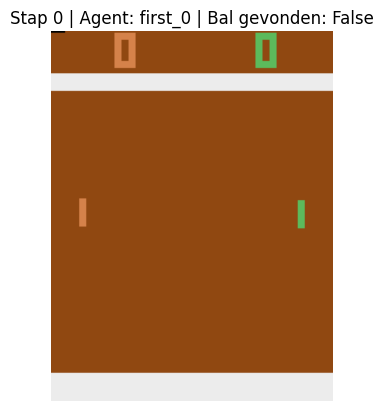

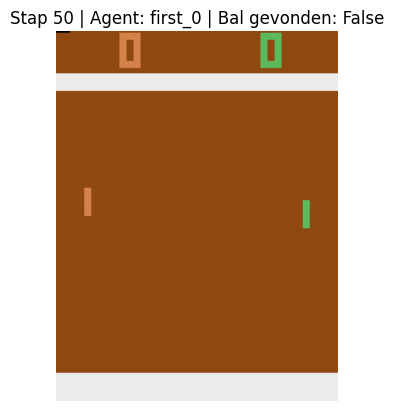

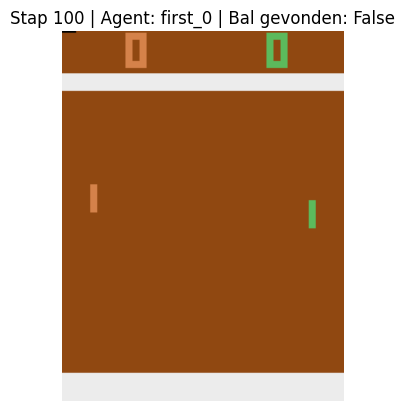

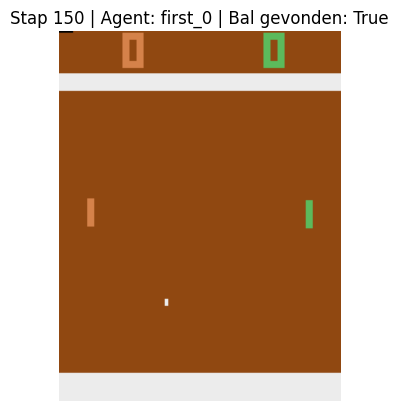

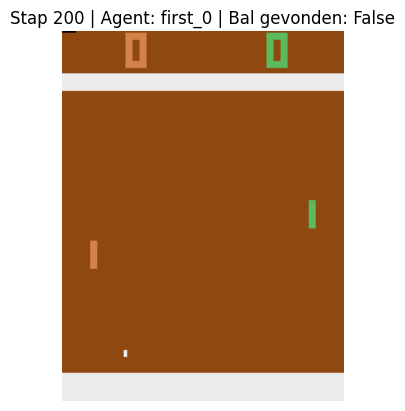

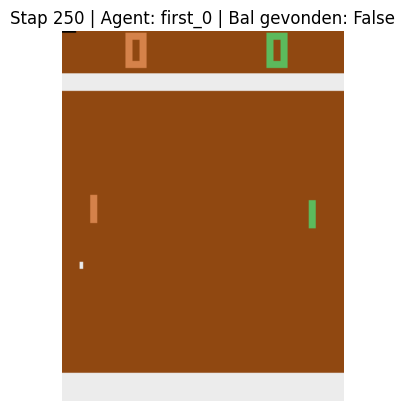

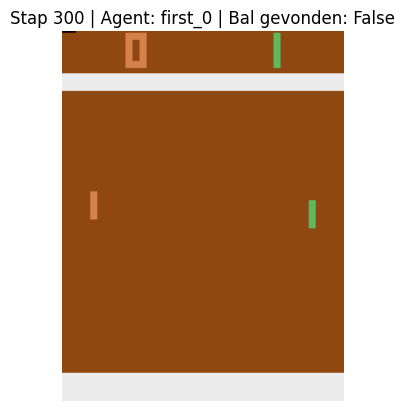

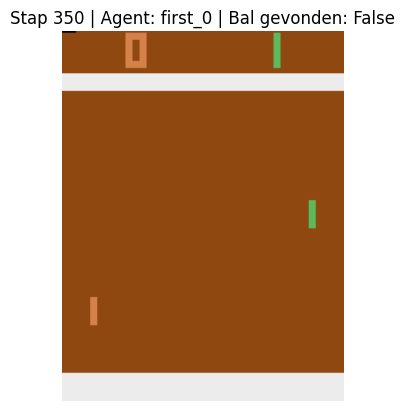

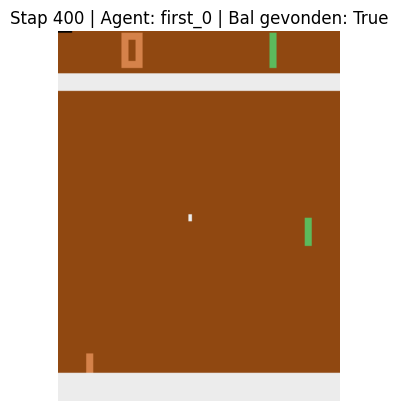

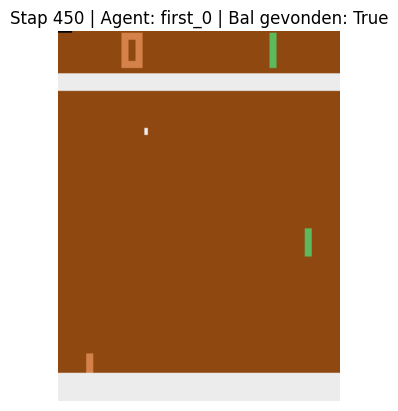

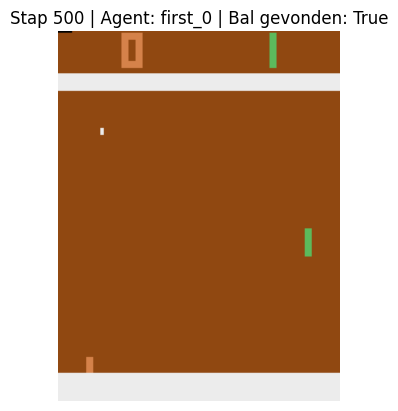

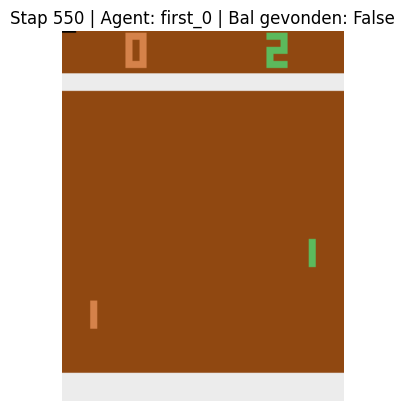

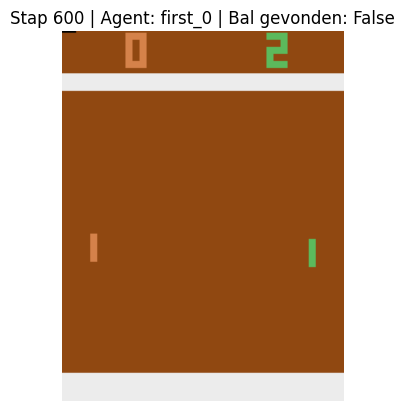

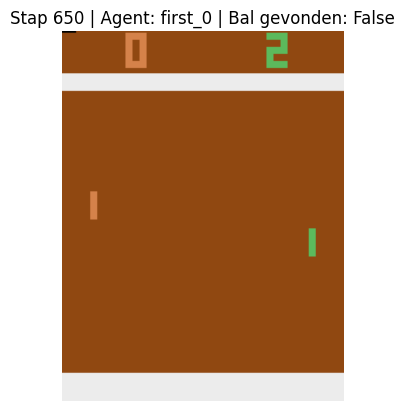

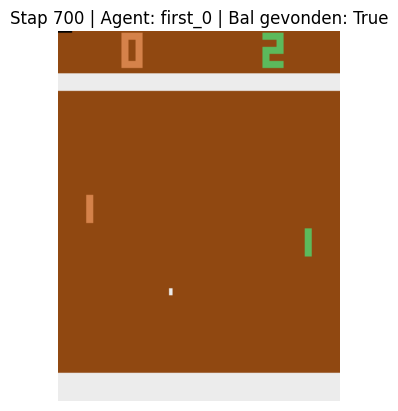

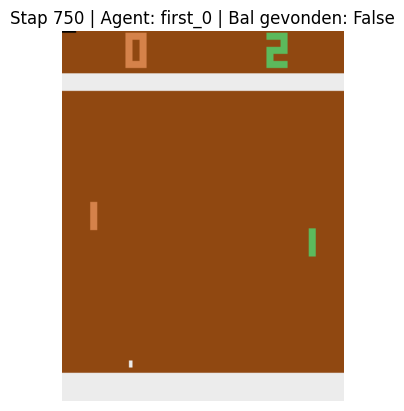

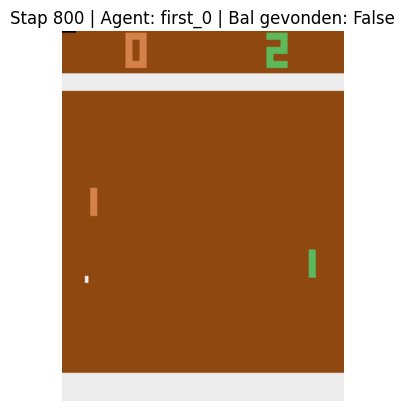

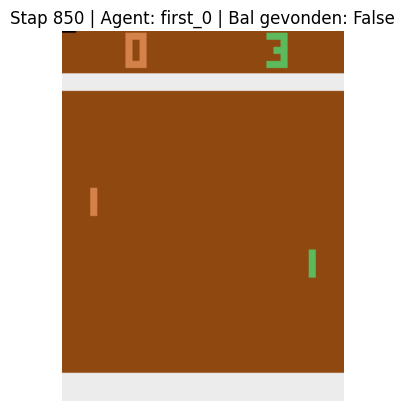

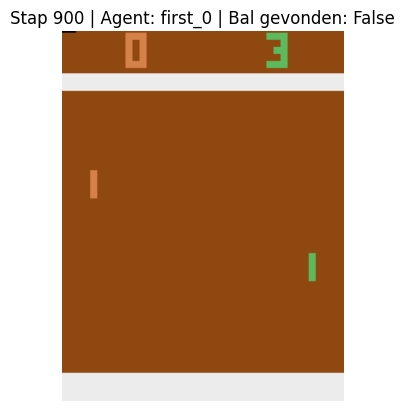

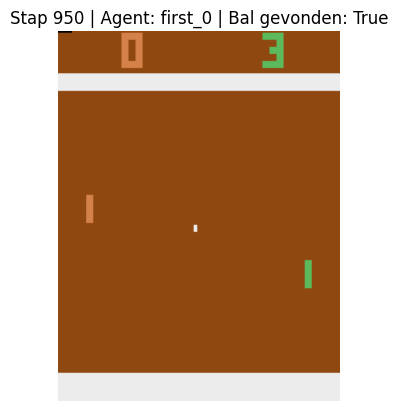

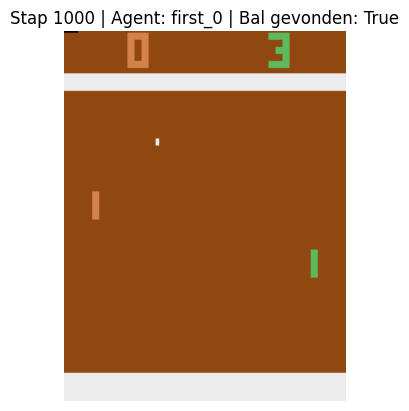

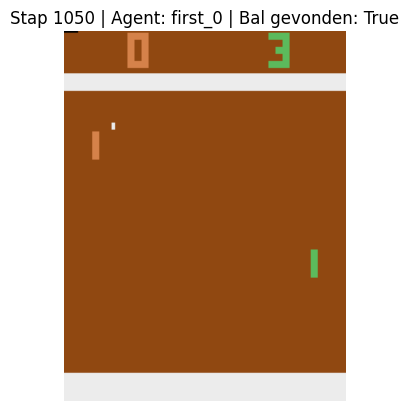

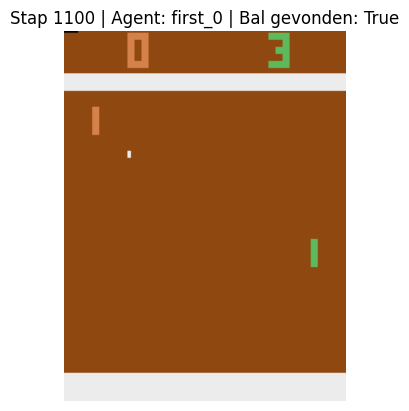

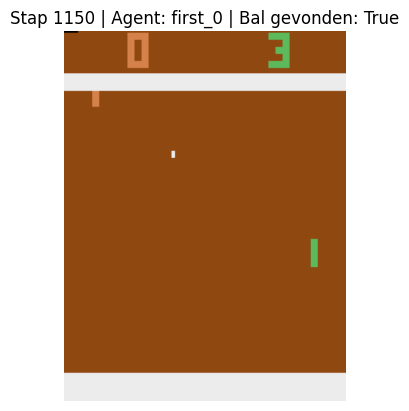

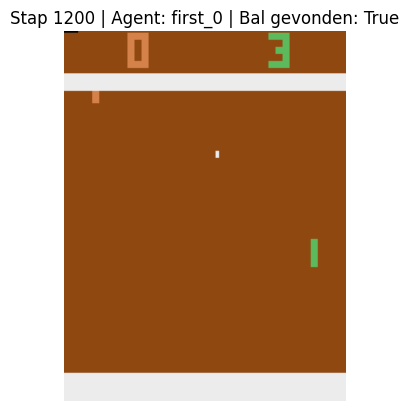

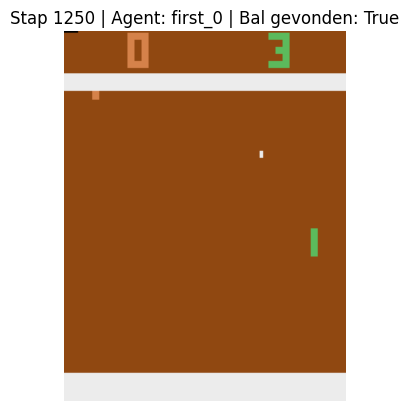

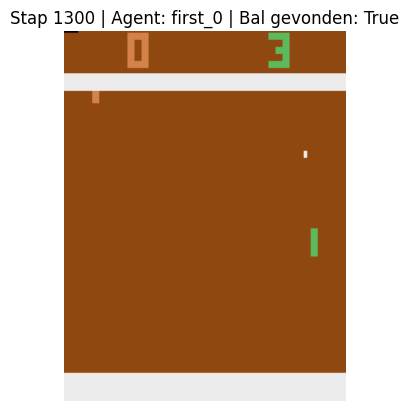

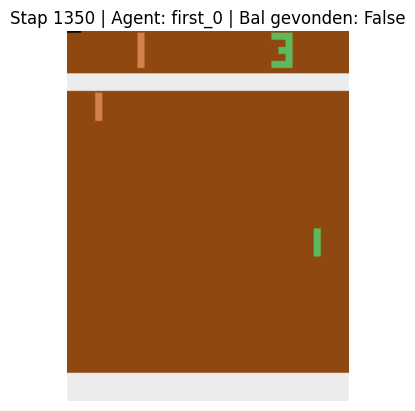

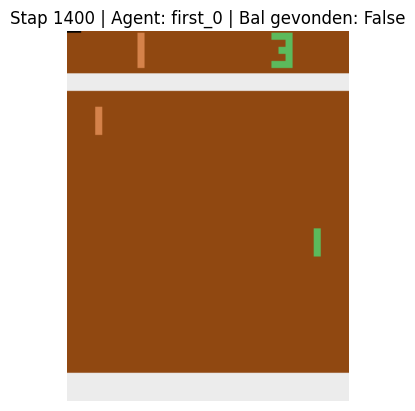

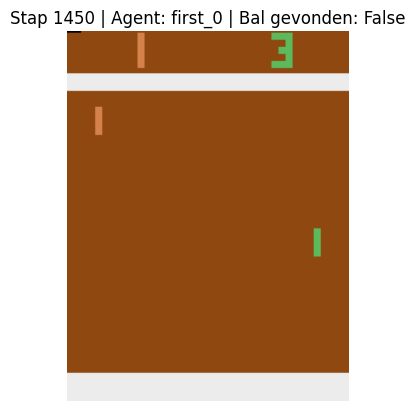

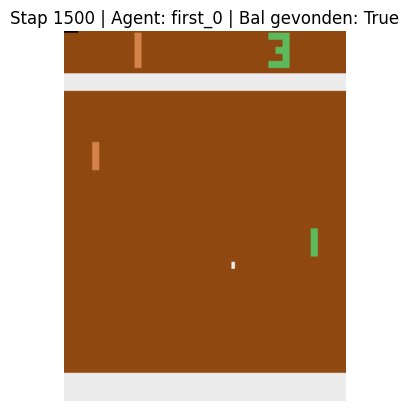

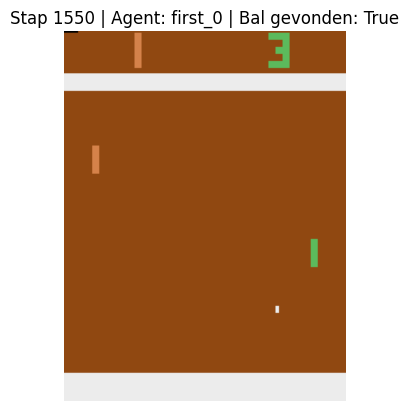

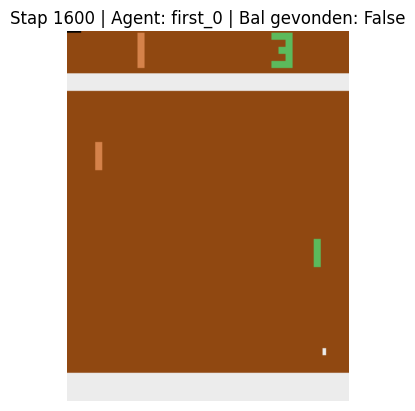

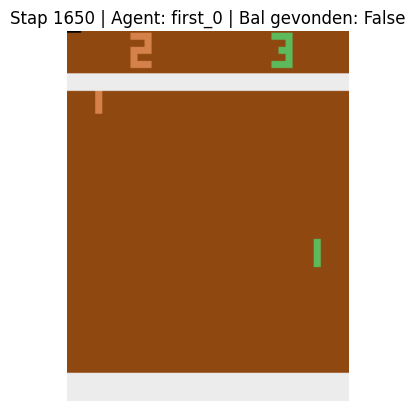

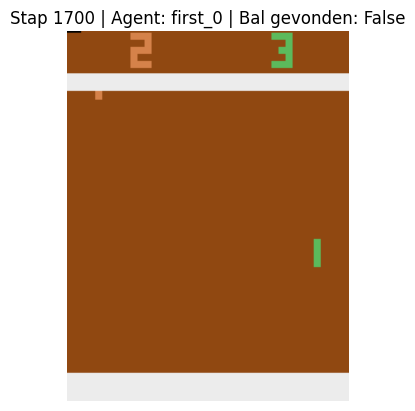

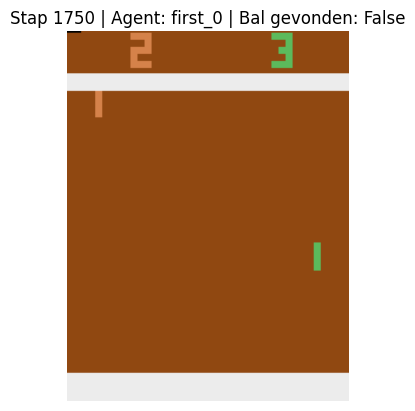

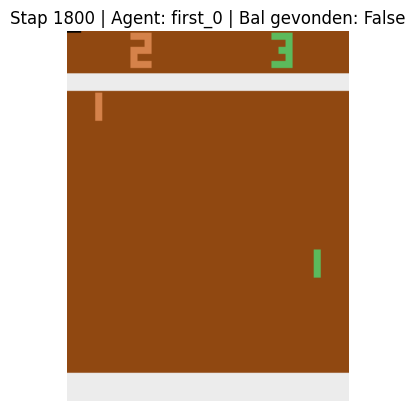

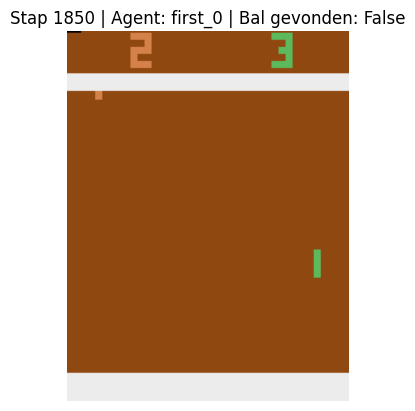

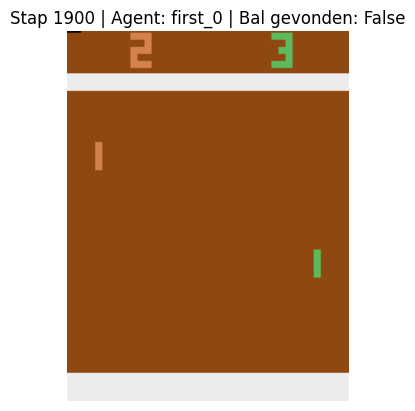

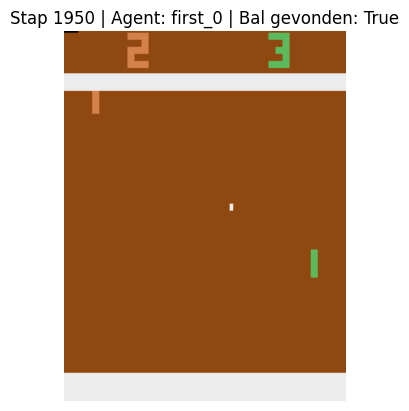

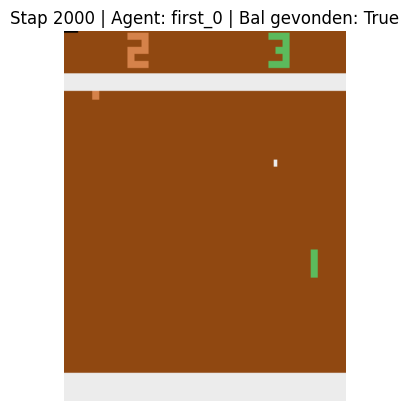

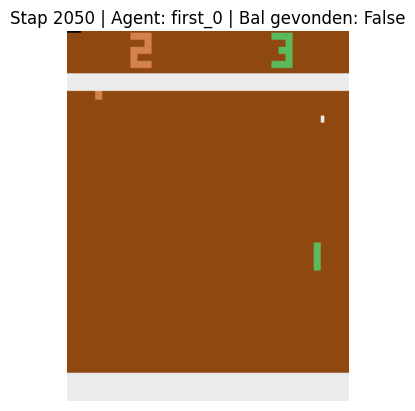

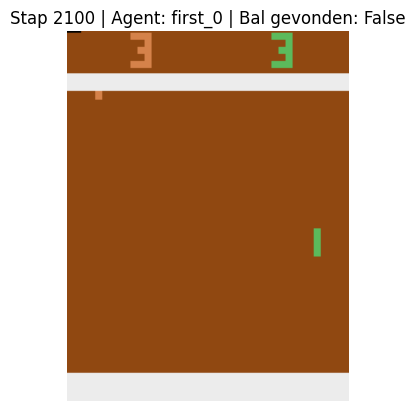

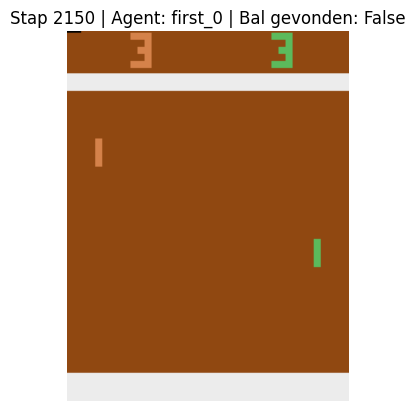

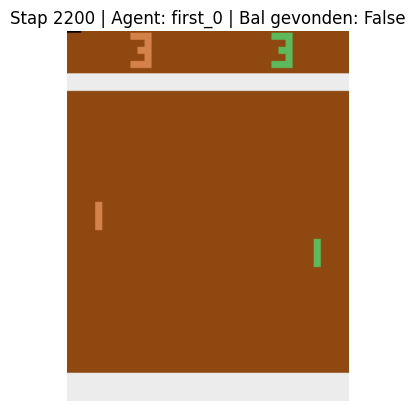

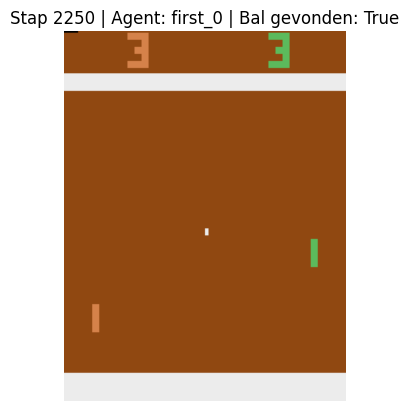

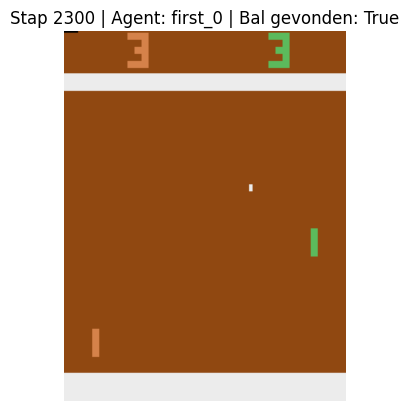

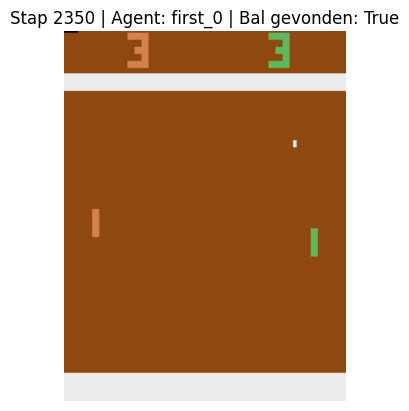

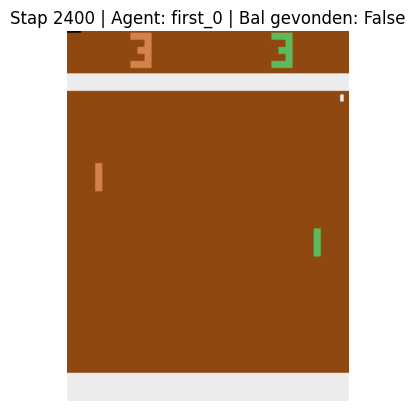

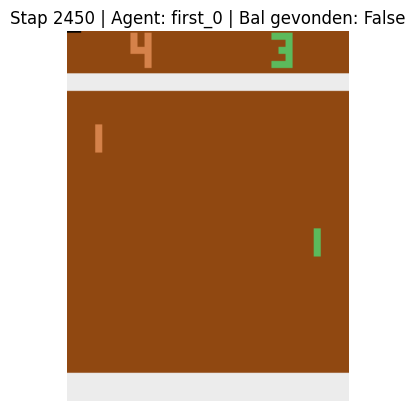

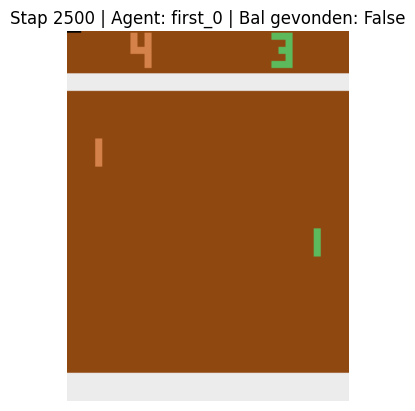

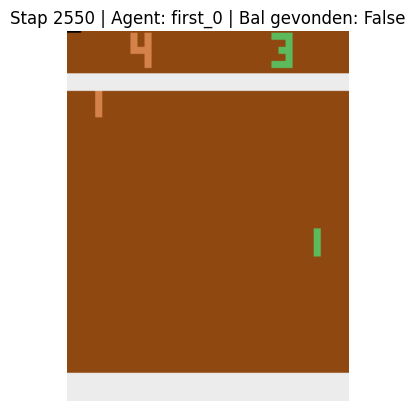

KeyboardInterrupt: 

In [5]:
import matplotlib.pyplot as plt
from pettingzoo.atari import pong_v3

env = pong_v3.env(render_mode="rgb_array")
env.reset(seed=42)

max_steps = 10000
step = 0

import random

# Maak de uitsnede NOG strakker: Y van 35 tot 180, X van 20 tot 140
def get_pos_safe(obs, color):
    play_area = obs[35:180, 20:140]
    indices = np.where(np.all(play_area == color, axis=-1))
    if len(indices[0]) > 0:
        return np.mean(indices[0]) + 35
    return None

for agent in env.agent_iter():
    observation, reward, termination, truncation, info = env.last()
    if termination or truncation:
        action = None
    else:
        ball_y = get_pos_safe(observation, BALL_COLOR)

        if agent == "first_0":
            my_y = get_pos_safe(observation, PADDLE_COLOR_1)
        else:
            my_y = get_pos_safe(observation, PADDLE_COLOR_2)

        # --- DE NIEUWE LOGICA ---

        # 1. Random actie invoeren voor de variatie (5% kans elke beurt)
        if random.random() < 0.02:
            action = env.action_space(agent).sample()

        # 2. Als er een bal is, volg deze (Strategie)
        elif ball_y is not None and my_y is not None:
            if ball_y < (my_y - 3):
                action = 2  # Omhoog
            elif ball_y > (my_y + 3):
                action = 3  # Omlaag
            else:
                action = 0

        # 3. FIX voor het vaststaan: Als er GEEN bal is (na score)
        else:
            # Dwing de groene (en oranje) speler om te 'vuren' en te bewegen
            # Dit schudt de emulator wakker na een punt
            if step % 2 == 0:
                action = 1 # FIRE
            else:
                # Beweeg een beetje willekeurig om niet op één plek te blijven plakken
                action = random.choice([2, 3])

    env.step(action)

    # Renderen om de 50 stappen voor de snelheid
    if step % 50 == 0:
        plt.imshow(env.render())
        plt.title(f"Stap {step} | Agent: {agent} | Bal gevonden: {ball_y is not None}")
        plt.axis("off")
        plt.show()

    step += 1
    if step >= max_steps:
        break

env.close()
print("Pong klaar!")

In [3]:
def get_pos_safe(obs, color):
    play_area = obs[35:180, 20:140]
    indices = np.where(np.all(play_area == color, axis=-1))
    if len(indices[0]) > 0:
        return np.mean(indices[0]) + 35
    return None

for agent in env.agent_iter():
    observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        action = None
    else:
        ball_y = get_pos_safe(observation, BALL_COLOR)

        if agent == "first_0":
            my_y = get_pos_safe(observation, PADDLE_COLOR_1)
        else:
            my_y = get_pos_safe(observation, PADDLE_COLOR_2)

        # --- DE NIEUWE LOGICA ---

        # 1. Random actie invoeren voor de variatie (5% kans elke beurt)
        if random.random() < 0.02:
            action = env.action_space(agent).sample()

        # 2. Als er een bal is, volg deze (Strategie)
        elif ball_y is not None and my_y is not None:
            if ball_y < (my_y - 3):
                action = 2  # Omhoog
            elif ball_y > (my_y + 3):
                action = 3  # Omlaag
            else:
                action = 0

        # 3. FIX voor het vaststaan: Als er GEEN bal is (na score)
        else:
            # Dwing de groene (en oranje) speler om te 'vuren' en te bewegen
            # Dit schudt de emulator wakker na een punt
            if step % 2 == 0:
                action = 1 # FIRE
            else:
                # Beweeg een beetje willekeurig om niet op één plek te blijven plakken
                action = random.choice([2, 3])

    env.step(action)

AttributeError: 'aec_to_parallel_wrapper' object has no attribute 'agent_iter'

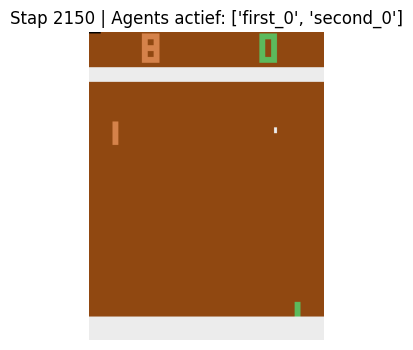

KeyboardInterrupt: 

In [6]:
max_steps = 5000
step = 0

while step < max_steps:
    # Maak een lijst met acties voor ALLE agents die NU in het spel zitten
    actions = {agent: get_rule_based_action(observations[agent], agent)
               for agent in env.agents}

    # Voer acties uit voor beide tegelijk
    observations, rewards, terminations, truncations, infos = env.step(actions)

    # Als iemand een punt tegen krijgt, reset DIRECT alles
    # Dit is waarom de tweede paddle voorheen stopte: hij werd 'terminated'
    if any(terminations.values()) or any(truncations.values()):
        observations, infos = env.reset()
        continue # Begin direct aan de nieuwe ronde

    # Visualisatie (elke 50 stappen voor snelheid in de browser)
    if step % 50 == 0:
        display.clear_output(wait=True)
        plt.figure(figsize=(6, 4))
        plt.imshow(env.render())
        plt.title(f"Stap {step} | Agents actief: {list(observations.keys())}")
        plt.axis("off")
        display.display(plt.gcf())
        plt.close()

    step += 1

env.close()
print("Klaar! Beide paddles bleven het hele spel actief.")